In [1]:
!pip install torch torchvision torchaudio

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp313-cp313-win_amd64.whl.metadata (6.9 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)
Using cached torchaudio-2.11.0-cp313-cp313-win_amd64.whl (328 kB)

   ---------------------------------------- 0/3 [torchaudio]
   ---------------------------------------- 0/3 [torchaudio]
   ---------------------------------------- 0/3 [torchaudio]
   ---------------------------------------- 0/3 [torchaudio]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torc

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


In [13]:
# Load data
train_df = pd.read_csv('labelled_training_data.csv')
val_df = pd.read_csv('labelled_validation_data.csv')
test_df = pd.read_csv('labelled_testing_data.csv')


In [28]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(763144, 16)
(188967, 16)
(188967, 16)


In [29]:
train_df.head()

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,1809.495787,381,7337,1,100,4026532231,close,ip-10-100-1-120,157,prctl,"[140662171848350, 11649800180280676]",5,0,"[{'name': 'option', 'type': 'int', 'value': 'P...",1,0
1,1809.495832,381,7337,1,100,4026532231,close,ip-10-100-1-120,3,close,[140662171777451],1,0,"[{'name': 'fd', 'type': 'int', 'value': 19}]",1,0
2,1809.495921,381,7337,1,100,4026532231,close,ip-10-100-1-120,1010,sched_process_exit,[],0,0,[],1,0
3,1894.139651,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,21,access,[],2,-2,"[{'name': 'pathname', 'type': 'const char*', '...",1,0
4,1894.142127,7347,7347,7341,0,4026531840,sh,ip-10-100-1-120,1005,security_file_open,"[139778263990104, 139778263906698]",4,0,"[{'name': 'pathname', 'type': 'const char*', '...",1,0


In [30]:
val_df.head()

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,124.439221,381,381,1,101,4026532232,systemd-resolve,ip-10-100-1-129,41,socket,"[139913106282763, 139913103116537, 94901962555...",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0
1,124.439751,378,378,1,100,4026532231,systemd-network,ip-10-100-1-129,41,socket,"[140343254628619, 93967981149065, 93967990898192]",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0
2,124.439958,1,1,0,0,4026531840,systemd,ip-10-100-1-129,1005,security_file_open,"[140074839310116, 8103505641674583864]",4,0,"[{'name': 'pathname', 'type': 'const char*', '...",0,0
3,124.440007,1,1,0,0,4026531840,systemd,ip-10-100-1-129,257,openat,[],4,12,"[{'name': 'dirfd', 'type': 'int', 'value': -10...",0,0
4,124.440037,1,1,0,0,4026531840,systemd,ip-10-100-1-129,5,fstat,[140074839307913],2,0,"[{'name': 'fd', 'type': 'int', 'value': 12}, {...",0,0


In [31]:
test_df.head()

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,129.050634,382,382,1,101,4026532232,systemd-resolve,ip-10-100-1-217,41,socket,"[140159195621643, 140159192455417, 94656731598...",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0
1,129.051238,379,379,1,100,4026532231,systemd-network,ip-10-100-1-217,41,socket,"[139853228042507, 93935071185801, 93935080775184]",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0
2,129.051434,1,1,0,0,4026531840,systemd,ip-10-100-1-217,1005,security_file_open,"[140362867191588, 8103505641674583858]",4,0,"[{'name': 'pathname', 'type': 'const char*', '...",0,0
3,129.051481,1,1,0,0,4026531840,systemd,ip-10-100-1-217,257,openat,[],4,17,"[{'name': 'dirfd', 'type': 'int', 'value': -10...",0,0
4,129.051522,1,1,0,0,4026531840,systemd,ip-10-100-1-217,5,fstat,[140362867189385],2,0,"[{'name': 'fd', 'type': 'int', 'value': 17}, {...",0,0


In [15]:
print(train_df.columns)
print(val_df.columns)
print(test_df.columns)

Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')


In [16]:
# Separate features and labels
X_train_df = train_df.drop('sus', axis=1)
y_train = train_df['sus']

X_val_df = val_df.drop('sus', axis=1)
y_val = val_df['sus']

X_test_df = test_df.drop('sus', axis=1)
y_test = test_df['sus']

In [17]:
# Use 'sus' as target
y_train = train_df['sus']
y_val = val_df['sus']
y_test = test_df['sus']

# Keep only numeric columns
X_train_df = train_df.drop(columns=['sus']).select_dtypes(include=['number'])
X_val_df = val_df.drop(columns=['sus']).select_dtypes(include=['number'])
X_test_df = test_df.drop(columns=['sus']).select_dtypes(include=['number'])

print(X_train_df.columns.tolist())
print(X_train_df.shape, X_val_df.shape, X_test_df.shape)

['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'eventId', 'argsNum', 'returnValue', 'evil']
(763144, 10) (188967, 10) (188967, 10)


In [18]:
X_val_df = X_val_df[X_train_df.columns]
X_test_df = X_test_df[X_train_df.columns]

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_val = scaler.transform(X_val_df)
X_test = scaler.transform(X_test_df)

In [20]:
### convert tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

In [23]:
##### create dataset & dataloader
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [22]:
## create model
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, weight_decay=1e-4)
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [24]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10, Train Loss: 0.0659, Train Acc: 0.9983, Val Loss: 0.0244, Val Acc: 0.9958
Epoch 2/10, Train Loss: 0.0087, Train Acc: 0.9989, Val Loss: 0.0041, Val Acc: 1.0000
Epoch 3/10, Train Loss: 0.0049, Train Acc: 0.9996, Val Loss: 0.0024, Val Acc: 1.0000
Epoch 4/10, Train Loss: 0.0042, Train Acc: 0.9996, Val Loss: 0.0017, Val Acc: 1.0000
Epoch 5/10, Train Loss: 0.0038, Train Acc: 0.9996, Val Loss: 0.0014, Val Acc: 1.0000
Epoch 6/10, Train Loss: 0.0036, Train Acc: 0.9996, Val Loss: 0.0012, Val Acc: 1.0000
Epoch 7/10, Train Loss: 0.0035, Train Acc: 0.9996, Val Loss: 0.0011, Val Acc: 1.0000
Epoch 8/10, Train Loss: 0.0034, Train Acc: 0.9996, Val Loss: 0.0010, Val Acc: 1.0000
Epoch 9/10, Train Loss: 0.0033, Train Acc: 0.9996, Val Loss: 0.0009, Val Acc: 1.0000
Epoch 10/10, Train Loss: 0.0033, Train Acc: 0.9996, Val Loss: 0.0008, Val Acc: 1.0000


In [25]:
val_accuracy = val_accuracies[-1]
print("Final Validation Accuracy:", val_accuracy)

Final Validation Accuracy: 0.9999523726364921


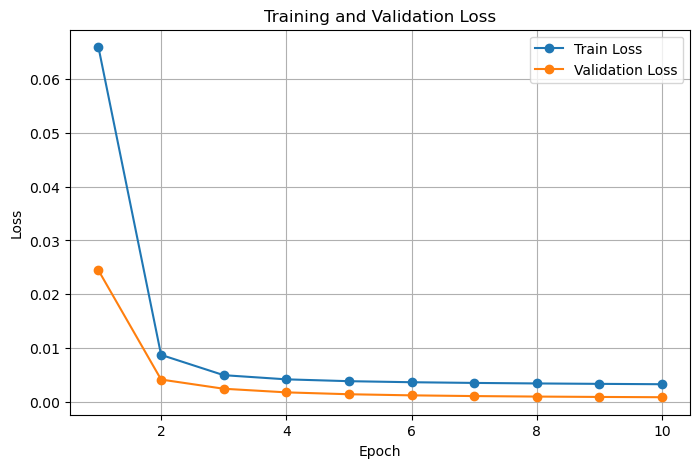

In [26]:
#### loss
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

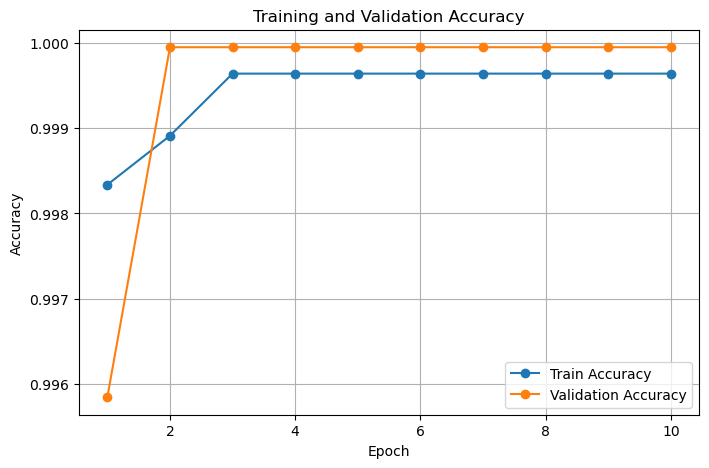

In [27]:
#### accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()